# EDA — Medical Abstracts, Fase 3

## Contexto e métodos

Objetivo: avaliar se o corpus sustenta o classificador educacional de **cinco categorias** e orientar as issues #1–#7. O grão é uma associação **abstract–categoria**, não um paciente único. Não há rótulo de urgência.

### Premissas e fontes

Os CSVs locais são a fonte de verdade. Referência: [corpus dos autores](https://github.com/sebischair/Medical-Abstracts-TC-Corpus), com licença publicada CC BY-SA 3.0. As contagens coincidem; os hashes abaixo identificam os arquivos analisados. Não há datas, hospitais, pacientes ou informações demográficas para avaliar temporalidade, representatividade ou equidade. Abstracts não são redistribuídos neste notebook.

Grupos textuais: Unicode NFKC, casefold e espaços normalizados. Conflitos são preservados, sem votar ou escolher uma categoria arbitrária. TF-IDF é ajustado somente no treino. Validação: primeiro fold estratificado por grupos, aproximadamente 80/20, seed 42; **não é uma validação cruzada de cinco modelos**. O teste já havia sido avaliado na implementação anterior e não é um holdout cego. Seus rótulos não selecionam hiperparâmetros.

Reprodução: `uv sync --frozen --all-groups` e `make notebook`. Tudo abaixo é recalculado em kernel limpo usando os módulos testados do projeto.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
from techchallenge_fase3.analysis import describe_corpus
from techchallenge_fase3.data import load_dataset, load_label_names
from techchallenge_fase3.modeling import (
    evaluate_model,
    test_partitions,
    train_model,
    validate_baseline,
)
from techchallenge_fase3.reporting import environment, file_hash

train = load_dataset(ROOT / "data/raw/medical_tc_train.csv")
test = load_dataset(ROOT / "data/raw/medical_tc_test.csv")
labels = load_label_names(ROOT / "data/raw/medical_tc_labels.csv")
eda = describe_corpus(train, test)
validation = validate_baseline(train)
model = train_model(train)
evaluation = {
    name: evaluate_model(model, data) if len(data) else None
    for name, data in test_partitions(train, test).items()
}
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
COLORS = {"Treino": "#245A81", "Teste": "#C07828"}
NAMES = [
    "Neoplasias",
    "Sistema digestivo",
    "Sistema nervoso",
    "Cardiovasculares",
    "Condições gerais",
]
FIGURES = ROOT / "reports/figures"
FIGURES.mkdir(parents=True, exist_ok=True)


def show_figure(name):
    plt.tight_layout()
    plt.savefig(FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

In [2]:
display(
    Markdown(f"""## Resumo executivo

- **{len(train):,} linhas de treino e {len(test):,} de teste**, sem nulos; {eda["overlap"]["combined_unique_texts"]:,} textos normalizados únicos no corpus combinado.
- **{eda["overlap"]["test_rows_seen_in_train"]:,} linhas de teste ({eda["overlap"]["test_seen_share"]:.2%}) repetem textos de treino**. O teste fornecido não mede apenas generalização a textos inéditos.
- **{eda["overlap"]["combined_conflicting_groups"]:,} grupos têm mais de uma categoria**. Isso é compatível com ambiguidade/múltiplos temas, mas a causa da anotação não pode ser estabelecida por esses campos.
- Macro-F1 na validação por grupos: **{validation["model"]["macro_f1"]:.4f}**; majoritário: **{validation["majority_baseline"]["macro_f1"]:.4f}**.
- Macro-F1 no teste completo: **{evaluation["supplied_test"]["macro_f1"]:.4f}**; nas **{evaluation["unseen_texts"]["rows"]:,} linhas de textos inéditos**: **{evaluation["unseen_texts"]["macro_f1"]:.4f}**. Populações diferentes não representam uma melhoria causal do modelo.

**Decisão:** prosseguir com o baseline leve e a API categórica, preservando conflitos e relatando grupos, classes e população inédita separadamente. Não prometer uso clínico.""")
)

## Resumo executivo

- **11,550 linhas de treino e 2,888 de teste**, sem nulos; 11,227 textos normalizados únicos no corpus combinado.
- **1,010 linhas de teste (34.97%) repetem textos de treino**. O teste fornecido não mede apenas generalização a textos inéditos.
- **2,929 grupos têm mais de uma categoria**. Isso é compatível com ambiguidade/múltiplos temas, mas a causa da anotação não pode ser estabelecida por esses campos.
- Macro-F1 na validação por grupos: **0.6650**; majoritário: **0.0999**.
- Macro-F1 no teste completo: **0.5982**; nas **1,878 linhas de textos inéditos**: **0.7601**. Populações diferentes não representam uma melhoria causal do modelo.

**Decisão:** prosseguir com o baseline leve e a API categórica, preservando conflitos e relatando grupos, classes e população inédita separadamente. Não prometer uso clínico.

## Dados e qualidade

In [3]:
display(
    pd.DataFrame(
        [
            {
                "arquivo": path.name,
                "bytes": path.stat().st_size,
                "sha256": file_hash(path),
            }
            for path in sorted((ROOT / "data/raw").glob("medical_tc_*.csv"))
        ]
    )
)
keys = [
    "rows",
    "unique_texts",
    "exact_duplicate_rows",
    "duplicate_text_rows_beyond_first",
    "conflicting_text_groups",
    "rows_in_conflicting_groups",
    "outside_api_length",
]
display(
    pd.DataFrame(
        [{key: eda[split][key] for key in keys} for split in ["train", "test"]],
        index=["Treino", "Teste"],
    )
)
display(
    pd.DataFrame(
        {
            "tipo": train.dtypes.astype(str),
            "nulos_treino": train.isna().sum(),
            "nulos_teste": test.isna().sum(),
        }
    )
)
assert len(train) == train.condition_label.value_counts().sum()
assert len(test) == sum(row["test"] for row in eda["classes"])
assert validation["shared_text_groups"] == 0

,arquivo,bytes,sha256
0,medical_tc_labels.csv,157,8a27ae03339c798103678efa8012f744a723ff71a80f2b...
1,medical_tc_test.csv,3586836,1eecea73c9ecad292c55e10403bd139fab9580545d6878...
2,medical_tc_train.csv,14254503,ad53aebc682d6b87a5647f619a079bb446d286fdc93bf0...


,rows,unique_texts,exact_duplicate_rows,duplicate_text_rows_beyond_first,conflicting_text_groups,rows_in_conflicting_groups,outside_api_length
Treino,11550,9445,0,2105,1956,4061,0
Teste,2888,2770,0,118,113,231,0


,tipo,nulos_treino,nulos_teste
condition_label,int64,0,0
medical_abstract,object,0,0


## Resultados

### Distribuição de classes

As categorias são exclusivas por linha, mas **não por texto**. Macro-F1 dá o mesmo peso às cinco classes; acurácia isolada favorece a maior classe. Os pesos balanceados são uma escolha fixa do baseline, não uma seleção pelo teste.

,label,name,train,test,share_difference_pp
0,1,neoplasms,2530,633,0.0135
1,2,digestive system diseases,1195,299,0.0069
2,3,nervous system diseases,1540,385,-0.0023
3,4,cardiovascular diseases,2441,610,-0.0123
4,5,general pathological conditions,3844,961,-0.0058


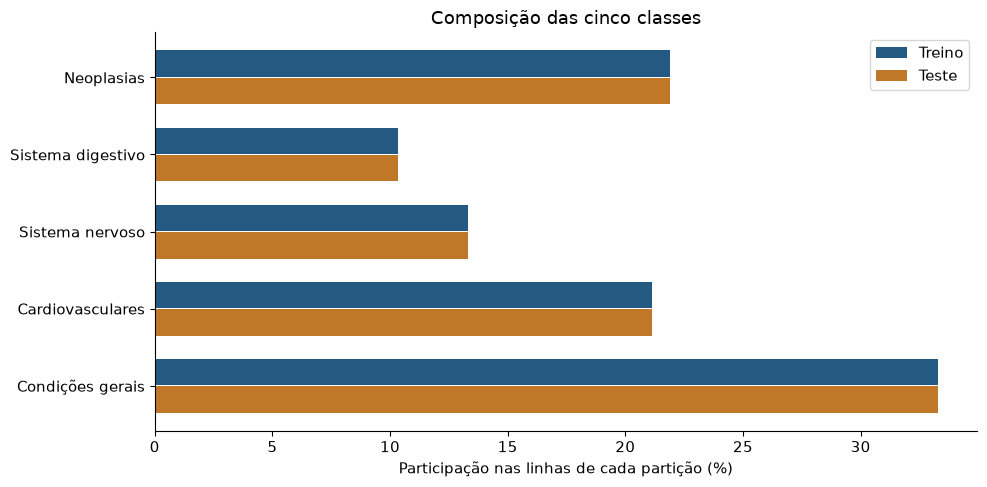

A maior classe tem **3.22 vezes** o volume da menor. Maior diferença treino/teste: **0.0135 ponto percentual**. Proporções semelhantes não provam independência textual.

In [4]:
classes = pd.DataFrame(eda["classes"])
display(classes[["label", "name", "train", "test", "share_difference_pp"]].round(4))
y = np.arange(5)
fig, ax = plt.subplots()
ax.barh(
    y - 0.18,
    classes.train_share * 100,
    height=0.34,
    color=COLORS["Treino"],
    label="Treino",
)
ax.barh(
    y + 0.18,
    classes.test_share * 100,
    height=0.34,
    color=COLORS["Teste"],
    label="Teste",
)
ax.set(
    yticks=y,
    yticklabels=NAMES,
    xlabel="Participação nas linhas de cada partição (%)",
    title="Composição das cinco classes",
)
ax.invert_yaxis()
ax.legend()
show_figure("class_distribution")
display(
    Markdown(
        f"A maior classe tem **{classes.train.max() / classes.train.min():.2f} vezes** o volume da menor. Maior diferença treino/teste: **{classes.share_difference_pp.abs().max():.4f} ponto percentual**. Proporções semelhantes não provam independência textual."
    )
)

### Comprimento e contrato da API

,train,test
count,11550.0,2888.0
mean,1229.1,1236.9
std,506.0,512.9
min,170.0,186.0
1%,311.0,315.0
5%,441.0,435.0
50%,1208.0,1221.5
95%,2049.0,2053.3
99%,2570.0,2640.7
max,3999.0,3542.0


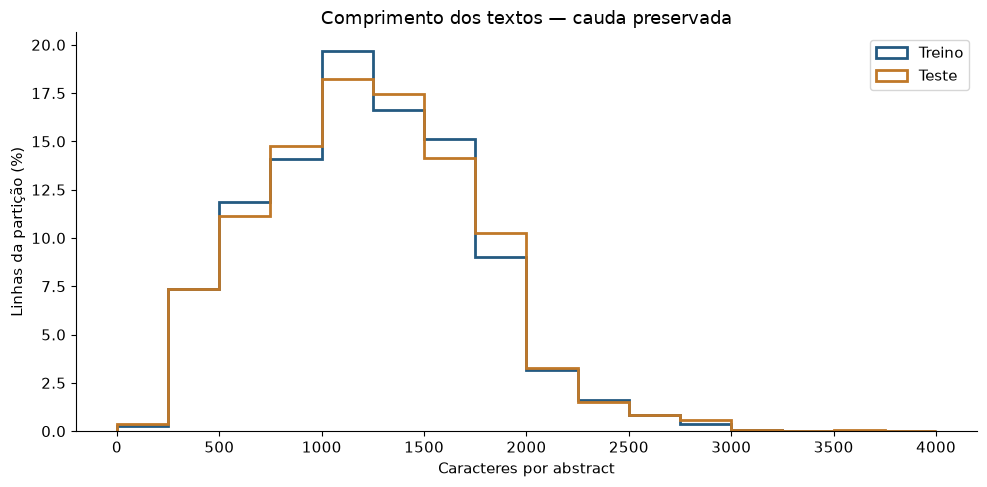

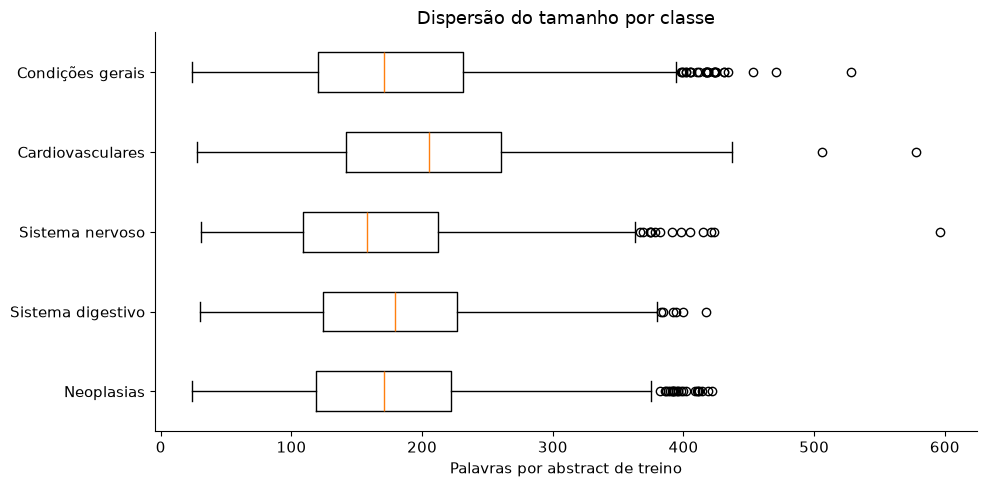

Máximo no treino: **3,999 caracteres**. O limite de 20.000 da API não trunca este corpus. KS exploratório: **D=0.0174**. Duplicatas violam independência; o p-valor não comprova ausência de drift. Não existem datas para analisar mudança temporal.

In [5]:
display(
    pd.DataFrame(
        {split: eda[split]["characters"] for split in ["train", "test"]}
    ).round(1)
)
fig, ax = plt.subplots()
for name, data in [("Treino", train), ("Teste", test)]:
    values = data.medical_abstract.str.len()
    ax.hist(
        values,
        bins=np.arange(0, 4250, 250),
        weights=np.ones(len(values)) * 100 / len(values),
        histtype="step",
        linewidth=2,
        label=name,
        color=COLORS[name],
    )
ax.set(
    xlabel="Caracteres por abstract",
    ylabel="Linhas da partição (%)",
    title="Comprimento dos textos — cauda preservada",
)
ax.legend()
show_figure("text_lengths")
fig, ax = plt.subplots()
ax.boxplot(
    [
        train.loc[train.condition_label.eq(label), "medical_abstract"]
        .str.split()
        .str.len()
        for label in labels
    ],
    tick_labels=NAMES,
    orientation="horizontal",
)
ax.set(
    xlabel="Palavras por abstract de treino", title="Dispersão do tamanho por classe"
)
show_figure("words_by_class")
display(
    Markdown(
        f"Máximo no treino: **{train.medical_abstract.str.len().max():,} caracteres**. O limite de 20.000 da API não trunca este corpus. KS exploratório: **D={eda['distribution']['character_length_ks_statistic']:.4f}**. Duplicatas violam independência; o p-valor não comprova ausência de drift. Não existem datas para analisar mudança temporal."
    )
)

### Repetições, conflitos e sobreposição

Nenhuma linha inteira se repete, mas isso não torna os textos únicos. O agrupamento ignora o rótulo e detecta ambiguidades que um `drop_duplicates()` das duas colunas não resolve. Sem revisar as anotações originais, não é possível distinguir erro de rotulagem de múltiplas categorias legítimas.

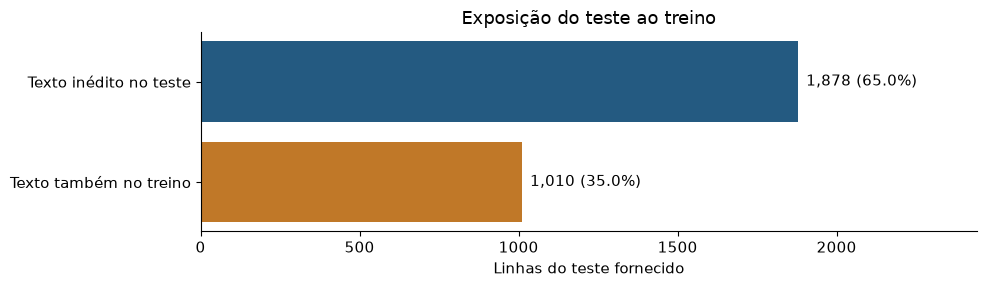

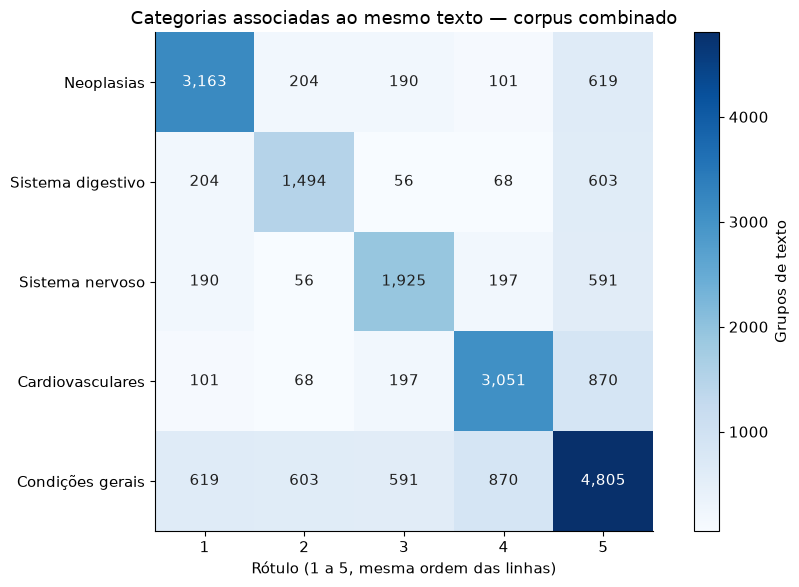

A diagonal conta grupos de cada classe; fora dela, grupos com ambos os rótulos. Teto empírico da acurácia para uma decisão única por texto neste corpus combinado: **77.76%** (soma da categoria mais frequente por grupo / linhas). Não é previsão de desempenho, teto universal ou evidência clínica.

In [6]:
overlap = eda["overlap"]
fig, ax = plt.subplots(figsize=(10, 3))
counts = [overlap["test_rows_seen_in_train"], overlap["test_unseen_rows"]]
bars = ax.barh(
    ["Texto também no treino", "Texto inédito no teste"],
    counts,
    color=["#C07828", "#245A81"],
)
ax.bar_label(
    bars, labels=[f"{value:,} ({value / len(test):.1%})" for value in counts], padding=6
)
ax.set(
    xlim=(0, max(counts) * 1.3),
    xlabel="Linhas do teste fornecido",
    title="Exposição do teste ao treino",
)
show_figure("test_overlap")
matrix = np.asarray(overlap["label_cooccurrence"])
fig, ax = plt.subplots(figsize=(9, 6))
view = ax.imshow(matrix, cmap="Blues")
for row in range(5):
    for col in range(5):
        ax.text(
            col,
            row,
            f"{matrix[row, col]:,}",
            ha="center",
            va="center",
            color="white" if matrix[row, col] > matrix.max() / 2 else "#202020",
        )
ax.set(
    xticks=range(5),
    yticks=range(5),
    xticklabels=range(1, 6),
    yticklabels=NAMES,
    xlabel="Rótulo (1 a 5, mesma ordem das linhas)",
    title="Categorias associadas ao mesmo texto — corpus combinado",
)
fig.colorbar(view, ax=ax, label="Grupos de texto")
show_figure("label_conflicts")
display(
    Markdown(
        f"A diagonal conta grupos de cada classe; fora dela, grupos com ambos os rótulos. Teto empírico da acurácia para uma decisão única por texto neste corpus combinado: **{overlap['single_label_empirical_accuracy_ceiling']:.2%}** (soma da categoria mais frequente por grupo / linhas). Não é previsão de desempenho, teto universal ou evidência clínica."
    )
)

### Vocabulário e similaridade lexical

Exploração: até 20.000 unigramas, `min_df=2`, stopwords em inglês, ajuste só no treino. Não confundir esse vocabulário exploratório com os 30.000 unigramas de produção. A tabela mostra maior TF-IDF médio por classe; não é explicação causal nem lista de palavras exclusivas.

In [7]:
lexical = eda["lexical"]
display(
    pd.DataFrame(
        {
            NAMES[int(label) - 1]: terms
            for label, terms in lexical["top_mean_tfidf_terms_by_class"].items()
        }
    )
)
near = lexical["near_duplicates"]
display(
    Markdown(f"""Vocabulário: **{lexical["vocabulary_size"]:,} termos**; esparsidade do treino: **{lexical["train_sparsity"]:.2%}**. Tokens fora do vocabulário limitado no teste: **{lexical["test_oov_token_share"]:.2%}**; vetores vazios no teste: **{lexical["test_zero_vectors"]}**.

Entre textos sem igualdade normalizada, **{near["unseen_test_rows_similarity_ge_090"]}** linhas atingem cosseno ≥ 0,90 com o vizinho de treino; **{near["unseen_test_rows_similarity_ge_095"]}** atingem ≥ 0,95. São limiares exploratórios: não provam ausência de paráfrases nem independência de pacientes. Não removemos linhas com base nos rótulos de teste.""")
)

,Neoplasias,Sistema digestivo,Sistema nervoso,Cardiovasculares,Condições gerais
0,patients,patients,patients,patients,patients
1,cancer,disease,pain,coronary,group
2,tumor,liver,brain,pressure,treatment
3,cell,hepatitis,cerebral,ventricular,disease
4,carcinoma,gastric,syndrome,artery,cases
5,tumors,esophageal,stroke,blood,acute
6,cells,bowel,disease,heart,patient
7,cases,biliary,nerve,hypertension,years
8,survival,treatment,treatment,myocardial,syndrome
9,breast,ulcer,patient,left,study


Vocabulário: **20,000 termos**; esparsidade do treino: **99.65%**. Tokens fora do vocabulário limitado no teste: **3.29%**; vetores vazios no teste: **0**.

Entre textos sem igualdade normalizada, **0** linhas atingem cosseno ≥ 0,90 com o vizinho de treino; **0** atingem ≥ 0,95. São limiares exploratórios: não provam ausência de paráfrases nem independência de pacientes. Não removemos linhas com base nos rótulos de teste.

### Baseline, generalização e análise de erros

TF-IDF + regressão logística balanceada, configuração fixa. Tokenização ASCII de dois ou mais caracteres alinhada com ONNX. Frequência sublinear desativada: o conversor instalado não reproduzia sua fórmula. Bigramas também foram removidos após quatro discrepâncias de vetorização; unigramas preservam a equivalência. As mudanças são de compatibilidade, não seleção pelos resultados do teste.

,rows,accuracy,macro_f1
Majoritário (validação),2310.0,0.3329,0.0999
Modelo (validação por grupos),2310.0,0.6623,0.6650
Teste completo,2888.0,0.5945,0.5982
Teste: texto inédito,1878.0,0.7604,0.7601
Teste: texto visto,1010.0,0.2861,0.3112


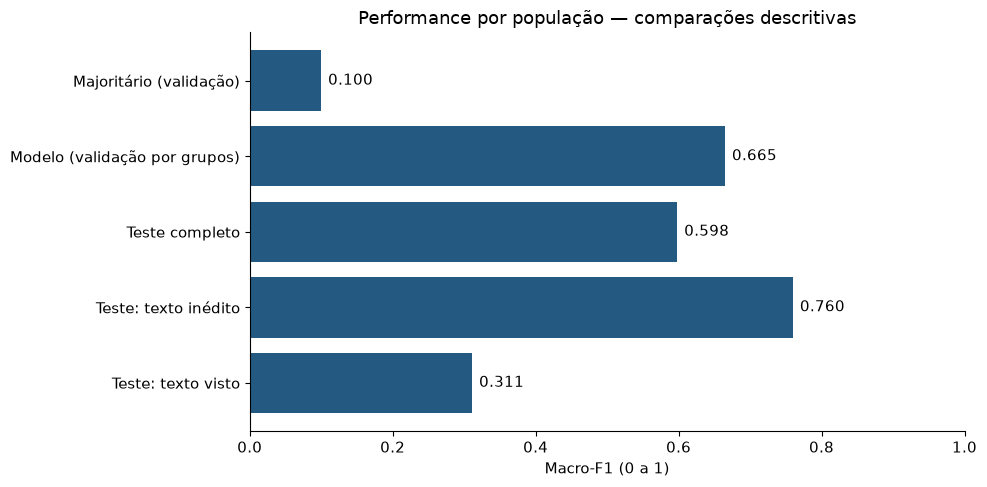

,precision,recall,f1-score,support
1,0.8214,0.8529,0.8368,469.0
2,0.6967,0.8855,0.7798,166.0
3,0.6577,0.7747,0.7114,253.0
4,0.8252,0.8420,0.8335,443.0
5,0.7256,0.5704,0.6387,547.0


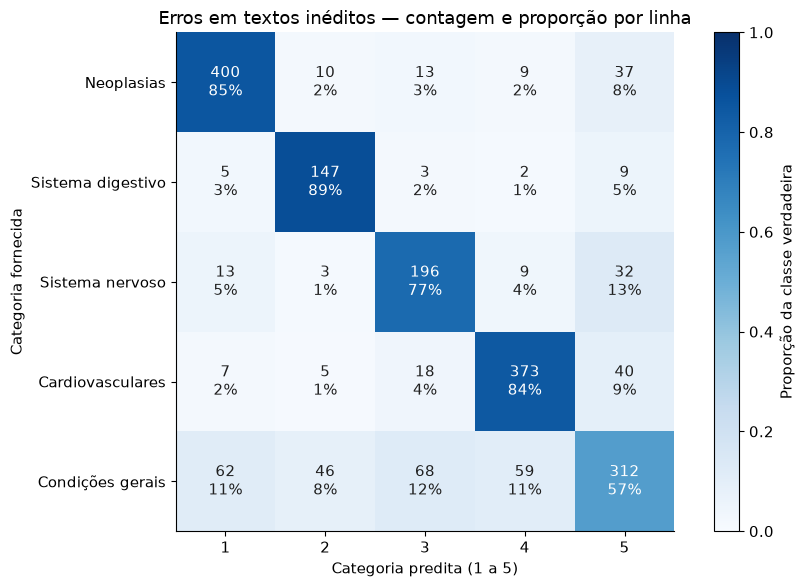

In [8]:
comparisons = {
    "Majoritário (validação)": validation["majority_baseline"],
    "Modelo (validação por grupos)": validation["model"],
    "Teste completo": evaluation["supplied_test"],
    "Teste: texto inédito": evaluation["unseen_texts"],
    "Teste: texto visto": evaluation["seen_texts"],
}
table = pd.DataFrame(
    {
        name: {key: result[key] for key in ["rows", "accuracy", "macro_f1"]}
        for name, result in comparisons.items()
    }
).T
display(table.round(4))
fig, ax = plt.subplots()
bars = ax.barh(table.index, table.macro_f1, color="#245A81")
ax.bar_label(bars, fmt="%.3f", padding=5)
ax.set(
    xlim=(0, 1),
    xlabel="Macro-F1 (0 a 1)",
    title="Performance por população — comparações descritivas",
)
ax.invert_yaxis()
show_figure("model_performance")
display(pd.DataFrame(evaluation["unseen_texts"]["per_class"]).T.round(4))
matrix = np.asarray(evaluation["unseen_texts"]["confusion_matrix"])
rates = matrix / matrix.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(9, 6))
view = ax.imshow(rates, vmin=0, vmax=1, cmap="Blues")
for row in range(5):
    for col in range(5):
        ax.text(
            col,
            row,
            f"{matrix[row, col]}\n{rates[row, col]:.0%}",
            ha="center",
            va="center",
            color="white" if rates[row, col] > 0.5 else "#202020",
        )
ax.set(
    xticks=range(5),
    yticks=range(5),
    xticklabels=range(1, 6),
    yticklabels=NAMES,
    xlabel="Categoria predita (1 a 5)",
    ylabel="Categoria fornecida",
    title="Erros em textos inéditos — contagem e proporção por linha",
)
fig.colorbar(view, ax=ax, label="Proporção da classe verdadeira")
show_figure("confusion_unseen")

In [9]:
probabilities = model.predict_proba(test.medical_abstract)
confidence = probabilities.max(axis=1)
correct = (
    model.classes_[probabilities.argmax(axis=1)] == test.condition_label.to_numpy()
)
confidence_table = pd.DataFrame({"confidence": confidence, "correct": correct})
confidence_table["faixa"] = pd.cut(
    confidence, bins=np.linspace(0, 1, 6), include_lowest=True
)
display(
    confidence_table.groupby("faixa", observed=True)
    .agg(
        linhas=("correct", "size"),
        confianca_media=("confidence", "mean"),
        acuracia=("correct", "mean"),
    )
    .round(4)
)
display(
    Markdown(
        "Confiança é a maior probabilidade do modelo, **não calibrada para uso clínico**. A tabela é descritiva; não ajusta calibrador nem estabelece limiares de triagem ou tratamento."
    )
)

,linhas,confianca_media,acuracia
faixa,,,
"(0.2, 0.4]",533,0.3426,0.4841
"(0.4, 0.6]",1158,0.4898,0.5717
"(0.6, 0.8]",763,0.6953,0.6186
"(0.8, 1.0]",434,0.8777,0.7488


Confiança é a maior probabilidade do modelo, **não calibrada para uso clínico**. A tabela é descritiva; não ajusta calibrador nem estabelece limiares de triagem ou tratamento.

## Conclusões e decisões para as issues

| Evidência / risco | Decisão | Atividade |
|---|---|---|
| Overlap textual, gravidade alta para a avaliação | Holdout por grupos e teste inédito explícito | #1, #7 |
| Conflitos de categoria, limitação alta do alvo único | Preservar rótulos; não ocultar ambiguidade nem mudar para múltiplos rótulos sem decisão de produto | #1, #6 |
| Desbalanceamento | Macro-F1, análise por classe, majoritário e pesos balanceados | #1, #7 |
| Textos completos e dentro do limite | Contrato automatizado; rejeitar entradas inválidas na API | #1, #2 |
| Conversão antiga alterava predições | Equivalência de rótulos e probabilidades em todo o teste e casos de borda | #3 |
| Inferência leve e esparsa | Latência com textos variados, aquecimento e rodadas pareadas; não quantizar sem ganho | #3 |
| Retreino pode falhar | Candidato isolado, avaliação e publicação atômica após aprovação | #5 |
| Observabilidade precisa funcionar | Validar fonte do Grafana, consultas e métricas de tráfego real | #4 |

O baseline supera o majoritário, mas mantém erros relevantes. A entrega comprova engenharia de ML, **não aptidão diagnóstica**. Não podemos inferir urgência, desempenho por hospital, equidade demográfica ou generalização a prontuários em português. O vídeo STAR deve mostrar também essas limitações.

### Verificação

Cálculos refeitos de cima para baixo. Totais reconciliados; ausência de overlap na validação verificada. Notebook e figuras contêm somente resultados agregados; CSVs permanecem locais. Os módulos reutilizados estão sob testes automatizados.

In [10]:
display(environment())

{'created_at': '2026-09-15T13:30:44.365080+00:00',
 'python': '3.11.15',
 'platform': 'Windows-10-10.0.26200-SP0',
 'packages': {'scikit-learn': '1.9.0',
  'numpy': '2.4.6',
  'pandas': '2.3.3',
  'onnxruntime': '1.29.0',
  'skl2onnx': '1.20.0'}}